## 2. DETECÇÃO DE FRAUDE EM TRANSAÇÕES FINANCEIRAS

- **Problema:** classificar transações sintéticas como fraudulentas/legítimas, simulando o desafio de detecção em sistemas como o PIX (desbalanceamento extremo).
- **Dataset:** PaySim Synthetic Financial — Kaggle — CC BY-SA 4.0 — ~470 MB, 6,3 M de transações.
- **Abordagem:** XGBoost / Random Forest com SMOTE/class weights vs. baseline por threshold. Meta: F1 ≥ 0.85 na classe minoritária.
- **Áreas exercitadas:** Ciência de Dados / Machine Learning.
- **Diferencial:** matriz de custo configurável via slider em dashboard Streamlit.
- **Tendência 2026:** após o MED 2.0 do BCB (fev/2026), modelos de score de fraude tornaram-se obrigatórios em pagamentos instantâneos.
- **Dificuldade:** *

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/paysim1")

print("Path to dataset files:", path)

100%|██████████| 178M/178M [00:06<00:00, 27.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2


#Entendimento Inicial

### Análise

O dataset possui **6.362.620 registros** e **11 variáveis**, indicando um volume grande de dados, adequado para problemas de detecção de fraude.

Em relação aos tipos de dados:
- Variáveis numéricas: `step`, `amount`, saldos e variáveis alvo  
- Variáveis categóricas: `type`, `nameOrig`, `nameDest`  

Não há indícios de valores nulos, já que o `count` é igual para todas as colunas.

---

### Insights

- A variável `amount` apresenta **alta variabilidade** (std elevado), indicando presença de valores extremos  
- Os saldos (`oldbalance` e `newbalance`) possuem muitos valores iguais a **zero**, especialmente nos quartis inferiores  
- O valor máximo das transações é muito elevado, indicando presença de **outliers**  
- A média de `isFraud` confirma que fraudes são **extremamente raras**  
- `isFlaggedFraud` tem média praticamente zero → quase nunca é ativado  

---

### Observações

- Os IDs (`nameOrig`, `nameDest`) são categóricos de **alta cardinalidade** e não podem ser usados diretamente em modelos sem tratamento  
- As variáveis de saldo (`oldbalance`, `newbalance`) podem causar **data leakage** se usadas diretamente na modelagem  
- A grande presença de zeros nos saldos pode indicar:
  - contas sem movimentação  
  - ausência de informação (especialmente para merchants)  
- A alta dispersão nos dados pode impactar modelos → pode ser necessário normalização ou transformação (log)  
- O dataset é **sintético**, podendo não refletir perfeitamente o comportamento do mundo real  

---

### Conclusão

O dataset apresenta boa integridade estrutural (sem valores nulos), porém possui alta variabilidade, presença significativa de outliers e muitos valores zerados em variáveis de saldo. Além disso, confirma-se o forte desbalanceamento da variável alvo, exigindo cuidados específicos na modelagem e avaliação dos modelos.

In [2]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

df = pd.read_csv(os.path.join(path, files[0]))
df.head()

['PS_20174392719_1491204439457_log.csv']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


#EDA (Análise Exploratória)

### Análise

Os tipos de transação mostram que `CASH_OUT` e `PAYMENT` são mais frequentes, enquanto `TRANSFER` e `DEBIT` possuem menor volume.

Ao cruzar com `isFraud`, observa-se que:
- Fraudes ocorrem **apenas em `CASH_OUT` e `TRANSFER`**
- `TRANSFER` possui a maior taxa de fraude  
- `CASH_OUT` tem menor taxa, mas alto volume absoluto  

A variável `amount` apresenta:
- Forte **assimetria à direita** (média > mediana)  
- Alta dispersão e presença de **outliers** (até ~92 milhões)  
- Concentração de valores baixos com cauda longa  

O boxplot (escala log) mostra que:
- `TRANSFER` e `CASH_OUT` concentram os maiores valores  
- `PAYMENT` e `DEBIT` possuem valores menores  

---

### Insights

- Fraudes estão concentradas em tipos específicos e de maior valor  
- `TRANSFER` é o mais arriscado proporcionalmente  
- `CASH_OUT` combina **alto volume + fraude**  
- Transações com valores mais altos tendem a estar associadas a fraude  
- A distribuição de `amount` reforça padrões importantes para detecção  

---

### Observações

- O padrão de fraude é muito claro → pode facilitar demais o modelo (dado simulado)  
- A variável `type` será extremamente relevante, com risco de dependência excessiva  
- A presença de outliers exige tratamento (ex: log1p)  
- Modelos sensíveis à escala podem ser impactados  
- Valores zero devem ser investigados  

---

### Conclusão

Os resultados mostram que fraude está fortemente associada a tipos específicos (`TRANSFER` e `CASH_OUT`) e a transações de maior valor. As variáveis `type` e `amount` são altamente preditivas, mas exigem cuidado devido à distribuição assimétrica, presença de outliers e possível simplificação do problema por padrões muito evidentes.


In [19]:
#Distribuição da variável type
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [25]:
#Distribuição da variável alvo
df['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.998709
1,0.001291


In [8]:
#Tipos de transação vs fraude
pd.crosstab(df['type'], df['isFraud'], normalize='index')

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998160,0.001840
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.992312,0.007688


In [10]:
#Distribuição de valores (amount)
df['amount'].describe()

,amount
count,6.362620e+06
mean,1.798619e+05
std,6.038582e+05
min,0.000000e+00
25%,1.338957e+04
50%,7.487194e+04
75%,2.087215e+05
max,9.244552e+07


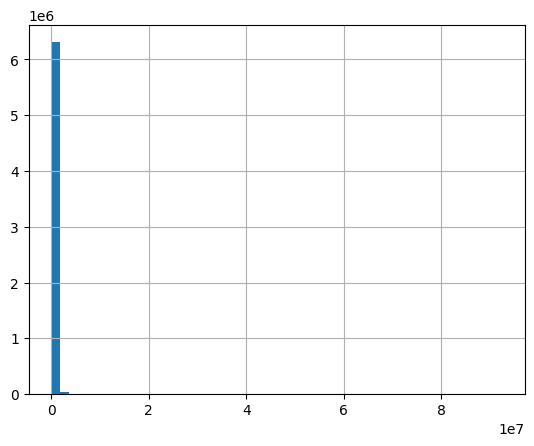

In [23]:
#Distribuição de valores (amount)
import matplotlib.pyplot as plt

df['amount'].hist(bins=50)
plt.show()

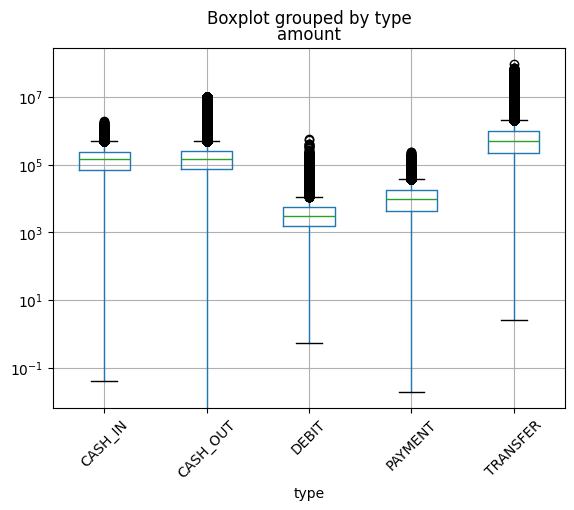

In [24]:
import matplotlib.pyplot as plt

df.boxplot(column='amount', by='type', rot=45)
plt.yscale('log')
plt.show()

In [12]:
#Análise temporal
df['step'].describe()

,step
count,6.362620e+06
mean,2.433972e+02
std,1.423320e+02
min,1.000000e+00
25%,1.560000e+02
50%,2.390000e+02
75%,3.350000e+02
max,7.430000e+02


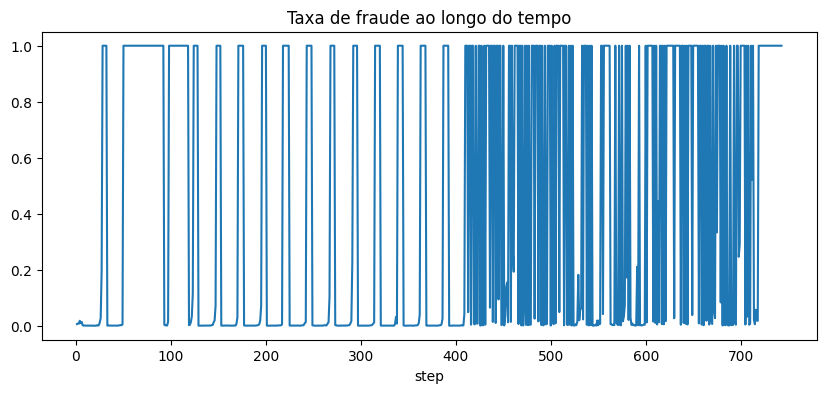

In [27]:
fraud_by_step = df.groupby('step')['isFraud'].mean()

fraud_by_step.plot(figsize=(10,4))
plt.title('Taxa de fraude ao longo do tempo')
plt.show()

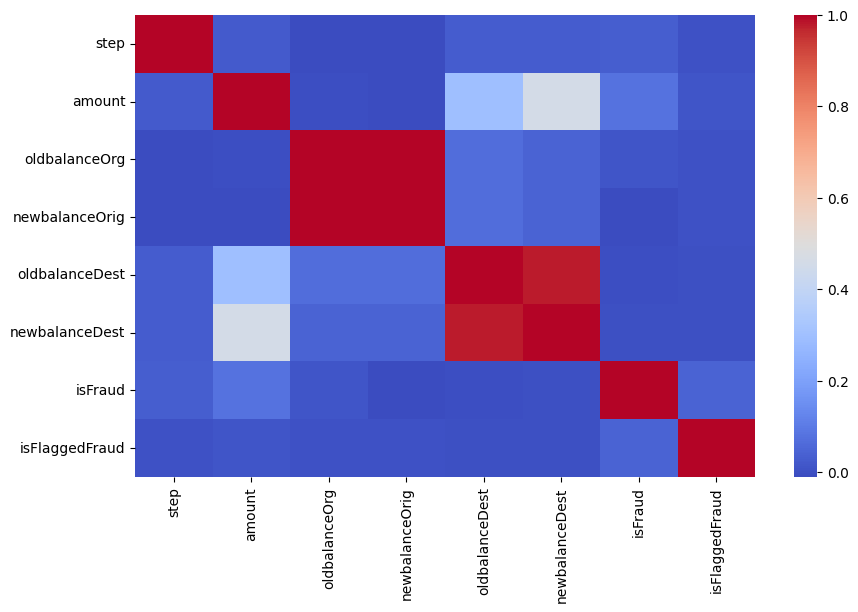

In [28]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()

A análise de correlação indica que não há relações lineares fortes com a variável de fraude, reforçando a necessidade de modelos mais robustos. Além disso, evidencia redundância nas variáveis de saldo, que devem ser tratadas com cautela na modelagem.

#Qualidade dos Dados (Data Quality)

### Análise

O dataset não apresenta valores nulos nem registros duplicados, indicando boa integridade estrutural inicial.

Entretanto, ao verificar consistência lógica:
- Há **5.413.997 inconsistências** na relação  
  `oldbalanceOrg - amount ≠ newbalanceOrig`  
- Isso indica que grande parte dos dados não segue a regra básica de atualização de saldo  

Na variável `isFlaggedFraud`:
- Apenas **16 transações foram sinalizadas** como fraude  
- Dessas, todas são realmente fraude  
- Porém, existem **8.197 fraudes que NÃO foram sinalizadas**

---

### Insights

- A ausência de nulos e duplicados sugere dataset bem estruturado  
- As inconsistências de saldo são muito frequentes → possível padrão do simulador ou comportamento de fraude  
- O sistema de detecção (`isFlaggedFraud`) tem:
  - **alta precisão** (quando marca, acerta)
  - **baixíssimo recall** (deixa passar quase todas fraudes)

---

### Observações

- As inconsistências podem estar ligadas a:
  - transações intermediárias
  - regras do simulador
  - comportamento fraudulento  
- `isFlaggedFraud` não é confiável como detector → regra muito limitada  
- Pode haver **data leakage** se variáveis de saldo forem usadas diretamente  

---

### Conclusão

Apesar da boa qualidade estrutural (sem nulos ou duplicados), o dataset apresenta inconsistências relevantes nas variáveis de saldo e um sistema de detecção de fraude extremamente limitado. Isso reforça a necessidade de uma modelagem mais robusta para capturar padrões de fraude de forma eficaz.

In [16]:
#Valores nulos
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [17]:
#Valores nulos
df.duplicated().sum()

np.int64(0)

In [15]:
#Inconsistências lógicas
(df['oldbalanceOrg'] - df['amount'] != df['newbalanceOrig']).sum()

np.int64(5413997)

In [18]:
pd.crosstab(df['isFlaggedFraud'], df['isFraud'])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16
